## Turbulent Channel Flow

This notebook demonstrates how to use P3D-L for generating turbulent channel flow fields. Note that the reference data is provided at [https://huggingface.co/datasets/thuerey-group/turbulent-channel-flow-pict](https://huggingface.co/datasets/thuerey-group/turbulent-channel-flow-pict).

Instantiate the model and load the pretrained weights

In [1]:
from p3d_surrogate import P3D_L
from p3d_surrogate.utils import get_state_dict_from_hub

model = P3D_L(channel_size=7, channel_size_out=4)

filename = "P3D_L_tcf_full_res.ckpt"
state_dict = get_state_dict_from_hub(filename)

model.load_state_dict(state_dict, strict=True)
model = model.cuda()
model = model.eval()

/home/holzschuh/anaconda3/envs/testp3d_v2/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/holzschuh/anaconda3/envs/testp3d_v2/lib/python3.12/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/home/holzschuh/anaconda3/envs/testp3d_v2/lib/python3.12/site-packages/torch/functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3595.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Define the sampling via flow matching using the ODE Euler scheduler

In [5]:
from p3d_surrogate.sampler.ode_euler import OdeEulerScheduler
from diffusers.utils.torch_utils import randn_tensor
import torch

CHANNEL_0_MEAN = 0.5034929; CHANNEL_0_STD = 0.22558229
CHANNEL_1_MEAN = -6.7011285e-07; CHANNEL_1_STD = 0.022445366
CHANNEL_2_MEAN = 0.00015084329; CHANNEL_2_STD = 0.034942694
CHANNEL_3_MEAN = 1.7268538e-12; CHANNEL_3_STD = 0.002972702


# model is trained on normalized data; denormalize the output
def denormalize(x):

    x[:, 0] = x[:, 0] * CHANNEL_0_STD + CHANNEL_0_MEAN
    x[:, 1] = x[:, 1] * CHANNEL_1_STD + CHANNEL_1_MEAN
    x[:, 2] = x[:, 2] * CHANNEL_2_STD + CHANNEL_2_MEAN
    x[:, 3] = x[:, 3] * CHANNEL_3_STD + CHANNEL_3_MEAN

    return x


def generate(model, deformation_tensor,
             num_inference_steps=100,
             generator=None, image_shape=None, **kwargs):

    scheduler = OdeEulerScheduler(num_train_timesteps=100)

    batch_dim = deformation_tensor.shape[0]

    if image_shape is None:
        image_shape = (batch_dim, 4, 96, 96, 192)


    x0 = randn_tensor(image_shape, generator=generator, device="cuda")

    input_tensor = torch.cat([x0, deformation_tensor], dim=1)

    scheduler.set_timesteps(num_inference_steps)

    for t in scheduler.timesteps:

        # 1. predict noise model_output
        t_batched = torch.full((batch_dim,), t.item(), device=model.device)

        model_output = model.forward(input_tensor, t_batched, **kwargs).sample

        # 2. compute previous image: x_t -> x_t-1
        x0 = scheduler.step(model_output, t, x0, generator=generator).prev_sample

        input_tensor = torch.cat([x0, deformation_tensor], dim=1)

    return denormalize(x0)

With `generate_samples_re()` we setup the generation of samples for the turbulent channel flow.

In [10]:
import time
from torch.cuda import amp
import numpy as np

batch_size = 8

def generate_samples_re(num_samples, num_inference_steps=20):

    samples = []

    class_labels = torch.ones(batch_size, dtype=torch.long) * 27 # Internal label for turbulent channel flow
    class_labels = class_labels.cuda()

    pde_parameters = torch.zeros(batch_size, dtype=torch.float) # Reynolds number; here P3D-L is trained unconditionally (Re always set to 0)
    pde_parameters = pde_parameters.cuda()

    deformation_tensor = torch.zeros(batch_size, 3, 96, 96, 192, dtype=torch.float) # Deformation tensor (displacement of grid points); unused here
    deformation_tensor = deformation_tensor.cuda()

    counter = 0
    while counter < num_samples:

        with torch.no_grad(), amp.autocast(enabled=True):
            time_ = time.time()
            fields_partial = generate(model, deformation_tensor, num_inference_steps=num_inference_steps, class_labels=class_labels, pde_parameters=pde_parameters)
            passed_time = time.time() - time_
            print('Passed time:', passed_time)
        fields_partial = fields_partial.cpu().numpy()
        samples.append(fields_partial)
        counter += batch_size
        print('Current counter: ', counter, ' / ', num_samples, ' ...')

    samples = np.concatenate(samples, axis=0)
    samples = samples[:num_samples]

    return samples

Now we generate 5 samples

In [11]:
fields = generate_samples_re(5)

/tmp/ipykernel_232399/933725132.py:23: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), amp.autocast(enabled=True):


Passed time: 22.369186639785767
Current counter:  8  /  5  ...


Finally, let's visualize the generated samples

Rendering Turbulent Channel Flow - Simulation 0...


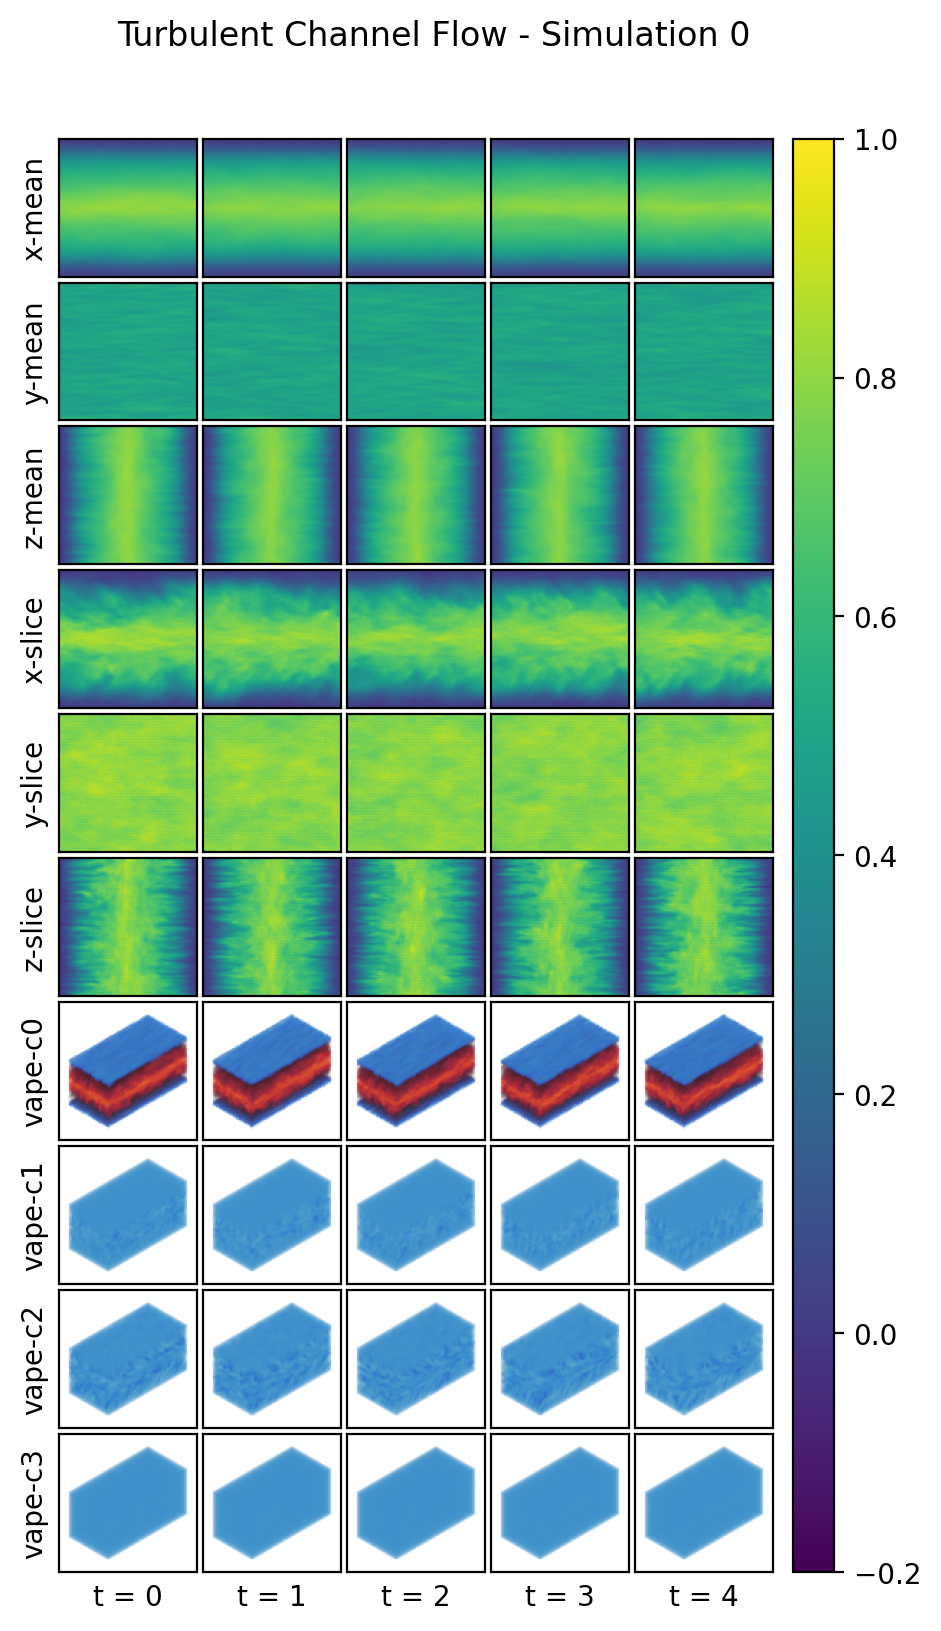

In [12]:
from p3d_surrogate.visualization import render_trajectory

NUM_FIELDS_VIS = min(5, fields.shape[0])

fig = render_trajectory(
    data=list(fields)[:NUM_FIELDS_VIS],
    dimension=3,
    sim_id=0,
    title='Turbulent Channel Flow',
    time_steps=NUM_FIELDS_VIS,
    steps_plot=NUM_FIELDS_VIS,
    vmin=-0.2,
    vmax=1.0,
)